# Regime-Shift: macro-aware tactical asset allocation

A Hidden Markov Model labels market regimes; convex optimization sets the portfolio stance per
regime; an expanding walk-forward with a one-day execution lag and 7.5 bps of cost decides whether
any of it survives contact with out-of-sample data.

**It does not.** This notebook runs the pipeline top to bottom and shows why: the HMM finds
*volatility* regimes, and on US 2016-2023 volatility carries no directional information. A
two-line volatility rule, costed identically, beats it.

Every function called here lives in `src/regime_shift/`. The notebook is the narrative, not the
implementation.

In [1]:
import warnings

import numpy as np
import pandas as pd

from regime_shift.backtest import run_backtest
from regime_shift.benchmarks import equal_weight, sixty_forty, vol_rule_regimes
from regime_shift.config import load_config
from regime_shift.data import build_master
from regime_shift.features import build_features
from regime_shift.metrics import bootstrap_ci, deflated_sharpe, optimal_block_length, summary
from regime_shift.plots import equity_drawdown, regime_overlay, transition_heatmap
from regime_shift.regime import RegimeModel, bic_sweep, dwell_times
from regime_shift.walkforward import run_walk_forward

warnings.filterwarnings("ignore")  # hmmlearn is noisy against numpy 2.5
pd.set_option("display.width", 200)

cfg = load_config()
cfg.hmm, cfg.walkforward, cfg.costs_bps, cfg.weight_cap

(HMMCfg(n_states=3, covariance_type='diag', n_iter=200, tol=0.01),
 WalkForward(min_train=252, test_size=63, step=63),
 7.5,
 0.6)

## 1. Data

Adjusted prices from Yahoo, cached to `data/` on first pull so every later run is offline. Macro
comes keyless from FRED and is forward-filled then lagged one day, so a row never sees a figure
published after its own close. If FRED is unreachable the master simply arrives without macro
columns rather than failing.

Asset columns are **log** returns.

In [2]:
master = build_master(cfg.universes["us"], cfg.dates["start"], cfg.dates["end"])
print(master.shape, list(master.columns))
master.tail(3)

(2263, 4) ['equity_ret', 'bond_ret', 'gold_ret', 'vix']


Ticker,equity_ret,bond_ret,gold_ret,vix
Date,,,,
2023-12-27,0.001807,0.017564,0.004528,12.43
2023-12-28,0.000378,-0.007290,-0.005832,12.47
2023-12-29,-0.002899,-0.009061,-0.001568,12.45


## 2. Causal features

Multi-window momentum (direction), realized volatility (stress), VIX and its change. Every rolling
window is right-aligned, so a feature at time t uses only rows at or before t.

Standardization is deliberately **not** done here. It happens inside each walk-forward fold using
train-only statistics, which is the difference between a leak-proof pipeline and a flattering
one.

In [3]:
feats = build_features(master, cfg)
print(feats.shape)
feats.tail(3)

(2138, 9)


Ticker,mom_5,mom_21,mom_63,mom_126,vol_5,vol_21,vol_63,vix,vix_chg
Date,,,,,,,,,
2023-12-27,0.003511,0.051381,0.115978,0.095520,0.138927,0.091169,0.120908,12.43,-0.559999
2023-12-28,0.017843,0.050769,0.110575,0.091964,0.056450,0.091317,0.120675,12.47,0.040000
2023-12-29,0.005506,0.048574,0.110106,0.077333,0.041648,0.092570,0.120745,12.45,-0.020000


## 3. Leak-proof walk-forward

Per fold: fit the scaler on train rows only, re-fit the HMM on scaled train, then decode the test
block with a **causal forward filter** carrying the train history forward. Whole-sequence Viterbi
would let a test day's label depend on later test days, so it is never used for decisions.

Labels are canonical: 0 is the calmest state, ascending to the most turbulent, and that ordering
is recomputed from train data in every fold so the labels stay comparable across refits.

In [4]:
regimes = run_walk_forward(feats, cfg)
oos = regimes.index
print(f"OOS {oos[0].date()} -> {oos[-1].date()}  n={len(oos)}")
print("label counts:", regimes.value_counts().sort_index().to_dict())
print("mean dwell (days):", {k: round(v, 1) for k, v in dwell_times(regimes.to_numpy()).items()})

OOS 2016-07-05 -> 2023-12-29  n=1886
label counts: {0: 666, 1: 841, 2: 379}
mean dwell (days): {0: 26.6, 1: 21.0, 2: 22.3}


## 4. The diagnostic that decides everything

Before backtesting, ask the only question that matters: **does the label predict the return we
actually earn?** The label is read at the close of t and the position it sets earns the return of
t+1, so that is the lag to measure at.

In [5]:
fwd = np.expm1(master.shift(-1)).loc[oos]
rows = []
for label, grp in fwd.groupby(regimes):
    r = grp["equity_ret"].dropna()
    rows.append({
        "label": label,
        "days": len(r),
        "eq_ann_ret": (1 + r).prod() ** (252 / len(r)) - 1,
        "eq_ann_vol": r.std(ddof=1) * np.sqrt(252),
        "eq_sharpe": r.mean() / r.std(ddof=1) * np.sqrt(252),
        "vix_mean": master.loc[grp.index, "vix"].mean(),
    })
pd.DataFrame(rows).set_index("label").round(3)

,days,eq_ann_ret,eq_ann_vol,eq_sharpe,vix_mean
label,,,,,
0,665,0.109,0.087,1.229,13.029
1,841,0.147,0.156,0.955,19.299
2,379,0.161,0.322,0.626,28.110


Volatility rises monotonically with the label, exactly as designed. **Return rises with it
too**, which is the opposite of what the strategy assumes. De-risking on the Crisis label sells the
highest-returning days, because the rebounds of April 2020 and late 2022 were as volatile as the
crashes that preceded them.

The BIC sweep says the same thing from the likelihood side: it keeps improving as states are
added, which is what happens when a mixture is fitting a fat-tailed continuum rather than
recovering discrete states.

In [6]:
from sklearn.preprocessing import StandardScaler

scaled = StandardScaler().fit_transform(feats.to_numpy(dtype=float))
bic = bic_sweep(scaled, covariance_type=cfg.hmm.covariance_type, n_iter=cfg.hmm.n_iter,
                tol=cfg.hmm.tol, random_state=cfg.seed)
{k: round(v) for k, v in bic.items()}

{2: 39821, 3: 34354, 4: 31349, 5: 29458}

## 5. Portfolio construction and costs

Per regime: Bull takes max-Sharpe (Schaible transform, since a ratio is not convex), Bear takes
minimum variance, Crisis takes minimum variance with equity hard-capped. Covariance is Ledoit-Wolf
shrunk and expected returns are pulled toward the grand mean, because raw sample moments blow up
any optimizer.

Weights decided at the close of t earn t+1's return. Between trades the book drifts, so a
non-rebalance day has exactly zero turnover and zero cost. **Benchmarks run through the same
engine**, so the comparison is like for like.

In [7]:
books = {
    "hmm_vol_ranked": run_backtest(regimes, master, cfg),
    "hmm_return_ranked": run_backtest(
        run_walk_forward(feats, cfg, rank_col="mom_21", rank_sign=-1.0).loc[oos], master, cfg),
    "hmm_vol_targeted": run_backtest(regimes, master, cfg, target_vol=0.10),
    "hmm_drawdown_feat": run_backtest(
        run_walk_forward(build_features(master, cfg, drawdown=True), cfg).loc[oos], master, cfg),
    "vol_rule_ablation": run_backtest(vol_rule_regimes(master, cfg).loc[oos], master, cfg),
    "60_40": sixty_forty(master, oos, cfg),
    "equal_weight": equal_weight(master, oos, cfg),
}

# Second engine (optional: uv sync --extra jump). A Statistical Jump Model penalises switching
# directly, so it is the natural check on whether the HMM's churn is what breaks it.
jump_labels = None
try:
    jump_labels = run_walk_forward(feats, cfg, engine="jump").loc[oos]
    books["jump_regime"] = run_backtest(jump_labels, master, cfg)
except ImportError as exc:
    print("jump engine skipped:", exc)

pd.DataFrame({k: summary(v) for k, v in books.items()}).T.round(3).sort_values(
    "sharpe", ascending=False
)

,ann_return,ann_vol,sharpe,sortino,max_drawdown,calmar,psr,turnover_ann,cost_drag_ann
vol_rule_ablation,0.098,0.103,0.958,1.369,-0.219,0.446,0.995,3.612,0.003
60_40,0.075,0.115,0.690,0.956,-0.276,0.273,0.969,0.409,0.000
jump_regime,0.066,0.101,0.682,0.962,-0.251,0.262,0.968,1.461,0.001
equal_weight,0.059,0.096,0.650,0.921,-0.230,0.258,0.961,0.421,0.000
hmm_return_ranked,0.057,0.097,0.620,0.875,-0.285,0.200,0.954,3.769,0.003
hmm_drawdown_feat,0.054,0.096,0.590,0.840,-0.280,0.191,0.946,3.875,0.003
hmm_vol_targeted,0.050,0.094,0.562,0.793,-0.273,0.182,0.937,4.104,0.003
hmm_vol_ranked,0.049,0.096,0.542,0.765,-0.287,0.170,0.930,4.188,0.003


Every HMM variant loses to both static benchmarks and to its own no-HMM ablation, while paying up
to ten times the turnover of 60/40. The Jump Model is the best of the regime family and still does
not clear 60/40.

Note what the two pre-registered fixes did. **Volatility targeting** barely moved anything, because
minimum variance already pins the book near 9.6% volatility, so a 10% target almost never binds:
the strategy's problem is that it is *already* too de-risked. The **drawdown feature** is judged
below on its stated criterion, not on its Sharpe.

## 6. Does a different estimator find better states?

The Jump Model penalises switching directly, so it is the sharpest available test of whether the
HMM's churn is the culprit.

In [8]:
def label_profile(labels):
    """Next-day equity behaviour per label, at the lag the strategy actually trades."""
    f = np.expm1(master["equity_ret"].shift(-1)).loc[labels.index]
    rows = []
    for label, r in f.groupby(labels):
        r = r.dropna()
        rows.append({"label": label, "days": len(r),
                     "eq_ann_ret": (1 + r).prod() ** (252 / len(r)) - 1,
                     "eq_ann_vol": r.std(ddof=1) * np.sqrt(252),
                     "eq_sharpe": r.mean() / r.std(ddof=1) * np.sqrt(252)})
    return pd.DataFrame(rows).set_index("label").round(3)


dd_labels = run_walk_forward(build_features(master, cfg, drawdown=True), cfg).loc[oos]
for name, lab in [("hmm", regimes), ("hmm + drawdown feature", dd_labels)] + (
    [("jump model", jump_labels)] if jump_labels is not None else []
):
    print(f"--- {name} ---")
    print(label_profile(lab).to_string())
    print("  dwell:", {k: round(v, 1) for k, v in dwell_times(lab.to_numpy()).items()})
if jump_labels is not None:
    print("hmm/jump label agreement:", round(float((jump_labels == regimes).mean()), 3))

--- hmm ---
       days  eq_ann_ret  eq_ann_vol  eq_sharpe
label                                         
0       665       0.109       0.087      1.229
1       841       0.147       0.156      0.955
2       379       0.161       0.322      0.626
  dwell: {0: 26.6, 1: 21.0, 2: 22.3}
--- hmm + drawdown feature ---
       days  eq_ann_ret  eq_ann_vol  eq_sharpe
label                                         
0       598       0.161       0.080      1.900
1       755       0.090       0.144      0.673
2       532       0.176       0.292      0.702
  dwell: {0: 24.0, 1: 18.0, 2: 29.6}
--- jump model ---
       days  eq_ann_ret  eq_ann_vol  eq_sharpe
label                                         
0      1164       0.135       0.128      1.051
1       615       0.128       0.193      0.720
2       106       0.200       0.466      0.624
  dwell: {0: 194.2, 2: 21.2, 1: 102.5}
hmm/jump label agreement: 0.586


Three readings of the same table, and they agree.

The **Jump Model** does exactly what it advertises: mean dwell jumps from ~27 days to ~194 and
turnover falls from 4.19x to 1.46x. Its states agree with the HMM only 58.6% of the time, so this
is genuinely a different partition of history. And its crisis state still carries the *highest*
forward equity return. Two unrelated estimators, low agreement, same broken ordering: the fault is
in the state space, not in the HMM.

The **drawdown feature** was the pre-registered attempt to fix that state space, since realized
volatility is symmetric in sign and cannot tell a crash from an equally violent rebound. The
criterion was fixed in advance: the crisis label's forward return has to turn **negative**. It
went from +16.1% to +17.6%. The feature failed on its own terms, and the small Sharpe improvement
it produced is not being counted as a win.

## 7. Deflation

A Sharpe reported once, from one strategy out of several tried, is biased upward. The probabilistic
Sharpe corrects for skew, fat tails and sample length; the deflated Sharpe further charges for how
many variants were searched. The interval below uses a stationary bootstrap with the block length
read off the data rather than guessed.

In [9]:
# Honest trial count: vol-ranked, return-ranked, conditional/unconditional moments, vol rule,
# jump engine, volatility targeting, drawdown feature. Searching more lowers every DSR below,
# which is precisely what it is there to do.
TRIALS = 7
for name, book in books.items():
    r = book["ret_net"]
    lo, hi = bootstrap_ci(r, n_boot=2000)
    print(f"{name:20s} block={optimal_block_length(r):5.1f}d  "
          f"CI=({lo:6.3f}, {hi:6.3f})  DSR@{TRIALS}trials={deflated_sharpe(r, TRIALS, 0.4):.3f}")

hmm_vol_ranked       block=  2.9d  CI=(-0.211,  1.263)  DSR@7trials=0.486


hmm_return_ranked    block=  2.9d  CI=(-0.127,  1.337)  DSR@7trials=0.571


hmm_vol_targeted     block=  2.9d  CI=(-0.184,  1.266)  DSR@7trials=0.508


hmm_drawdown_feat    block=  2.6d  CI=(-0.128,  1.343)  DSR@7trials=0.538


vol_rule_ablation    block=  2.2d  CI=( 0.238,  1.652)  DSR@7trials=0.863


60_40                block=  1.9d  CI=(-0.023,  1.422)  DSR@7trials=0.643


equal_weight         block=  2.1d  CI=(-0.086,  1.382)  DSR@7trials=0.602


jump_regime          block=  3.0d  CI=(-0.092,  1.399)  DSR@7trials=0.636


Only the simple rule has an interval that excludes zero. Every regime variant, HMM and Jump Model
alike, straddles it. That is the honest way to say the result is not there.

## 8. Figures

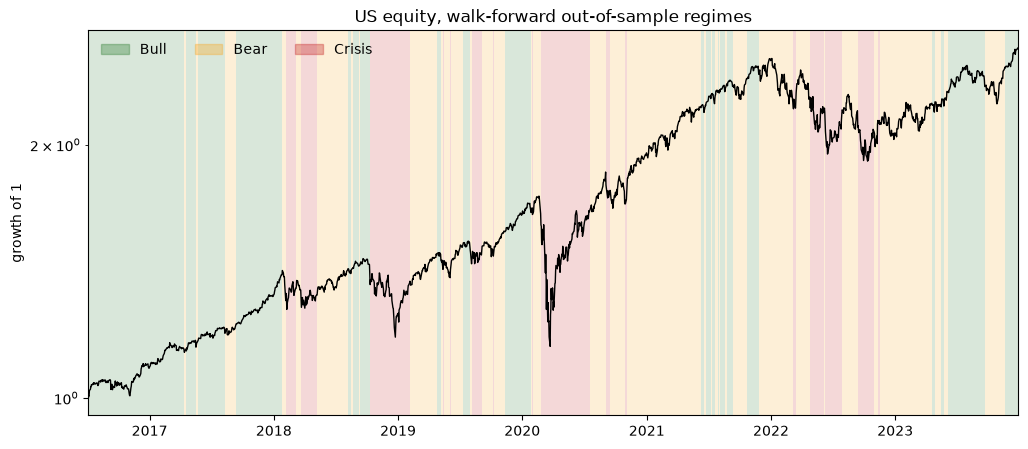

In [10]:
level = np.exp(master["equity_ret"].cumsum()).loc[oos]
ax = regime_overlay(level / level.iloc[0], regimes)
ax.set_title("US equity, walk-forward out-of-sample regimes");

The overlay is the encouraging part: with no future information the filter independently flags
Feb 2018, Q4 2018, COVID and 2022. The regime detector works. It is the leap from *volatile* to
*sell* that does not.

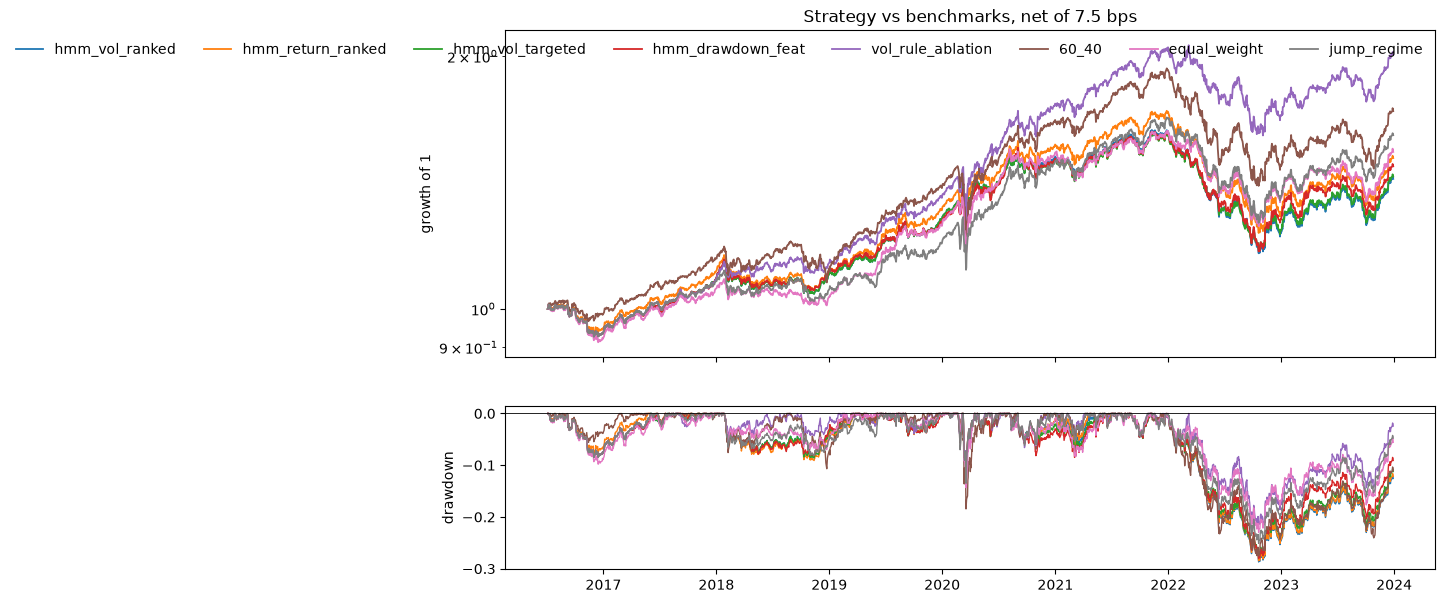

In [11]:
axes = equity_drawdown(books)
axes[0].set_title(f"Strategy vs benchmarks, net of {cfg.costs_bps} bps");

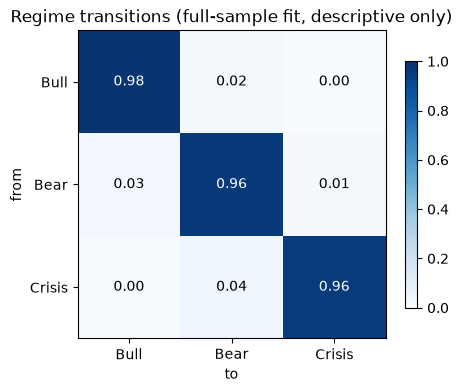

In [12]:
model = RegimeModel(n_states=cfg.hmm.n_states, covariance_type=cfg.hmm.covariance_type,
                    n_iter=cfg.hmm.n_iter, tol=cfg.hmm.tol, random_state=cfg.seed
                    ).fit(scaled, rank_by=feats["vol_21"].to_numpy())
ax = transition_heatmap(model.transition_matrix())
ax.set_title("Regime transitions (full-sample fit, descriptive only)");

## Conclusion

The engine is sound and the regimes are real: persistent (diagonal 0.96-0.98), economically legible
(VIX 13 / 19 / 28), and detected without lookahead. The strategy still fails, for a reason worth
stating plainly: **volatility regimes are not return regimes**. A state variable has to predict
direction before a directional bet on it can pay, and this one predicts variance.

Three independent attempts to rescue it were made, and all three failed in the same direction:

1. **A different estimator.** The Statistical Jump Model produces far more persistent states
   (dwell 194 days vs 27) at a third of the turnover, agrees with the HMM only 58.6% of the time,
   and lands on the same broken return ordering. Different machinery, identical failure.
2. **A different bet.** Volatility targeting barely binds, because minimum variance already holds
   the book below the target. The strategy is not taking too much risk; it is taking too little
   and forfeiting return.
3. **A different state space.** Drawdown-from-peak failed its own pre-registered criterion: the
   crisis label's forward return stayed positive (+17.6%).

The convergence is what makes the finding credible. One failed variant is a bad afternoon; three
failing the same way, across two estimators and two universes, is evidence about the problem
rather than about the implementation.

What would actually be needed is a state variable carrying information about *direction* that
survives out-of-sample: credit spreads, breadth, earnings revisions, or positioning. Realized
volatility and VIX are symmetric in sign and simply cannot supply it. Note also that the search
budget is now largely spent: at 7 trials the deflated Sharpe threshold has risen enough that any
further variant needs a materially bigger raw Sharpe just to stand still.